In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv(
    "data/cleaned_superstore.csv",
    encoding="latin1"
)

df["Order Date"] = pd.to_datetime(df["Order Date"], errors="coerce")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], errors="coerce")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [2]:
print("Dataset Shape:", df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Shape: (9994, 21)

Data Types:
Row ID                    int64
Order ID                    str
Order Date       datetime64[us]
Ship Date        datetime64[us]
Ship Mode                   str
Customer ID                 str
Customer Name               str
Segment                     str
Country                     str
City                        str
State                       str
Postal Code               int64
Region                      str
Product ID                  str
Category                    str
Sub-Category                str
Product Name                str
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object

Missing Values:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID 

In [3]:
df.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355,2016-05-03 23:06:58.571142,55190.379428,229.858001,3.789574,0.156203,28.656896
min,1.000000,2014-01-03 00:00:00,2014-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,2015-05-23 00:00:00,2015-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,2016-06-26 00:00:00,2016-06-29 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,2017-05-14 00:00:00,2017-05-18 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,2017-12-30 00:00:00,2018-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000
std,2885.163629,NaN,NaN,32063.693350,623.245101,2.225110,0.206452,234.260108


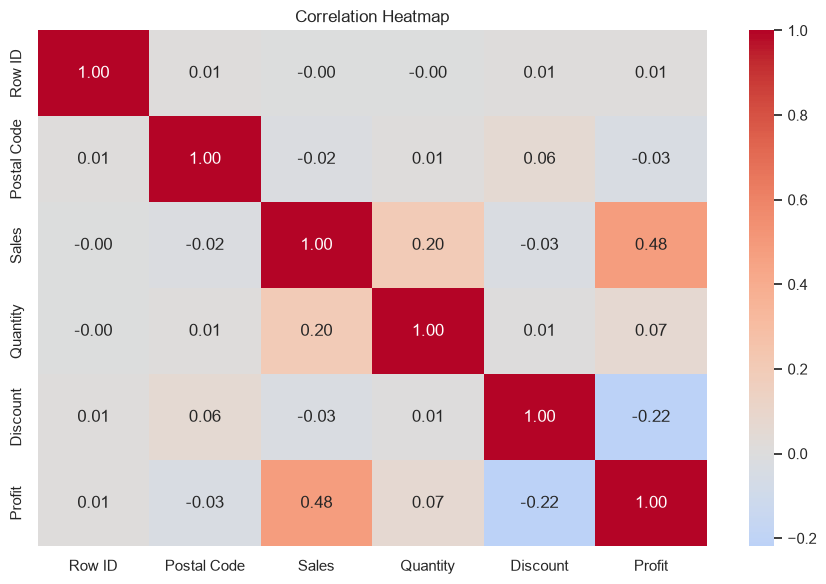

In [4]:
numeric_df = df.select_dtypes(include="number")

plt.figure(figsize=(9, 6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

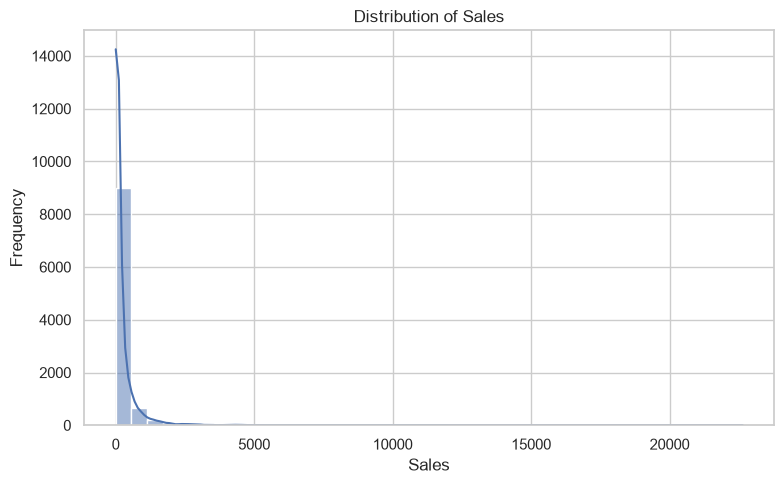

In [5]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df["Sales"],
    bins=40,
    kde=True
)

plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### Observation
Most orders have relatively low sales values, while a smaller number of orders have much higher sales values, creating a right-skewed distribution.

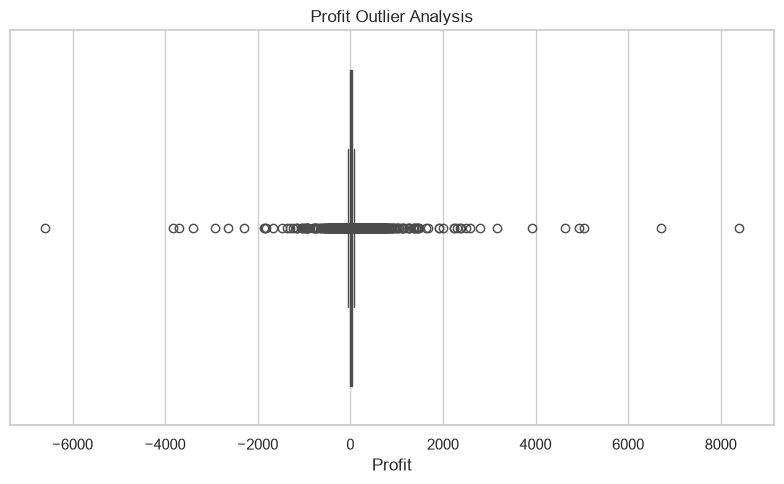

In [6]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=df["Profit"])

plt.title("Profit Outlier Analysis")
plt.xlabel("Profit")

plt.tight_layout()
plt.show()

### Observation
The boxplot shows the distribution of profit and highlights unusually high and low profit values as potential outliers.

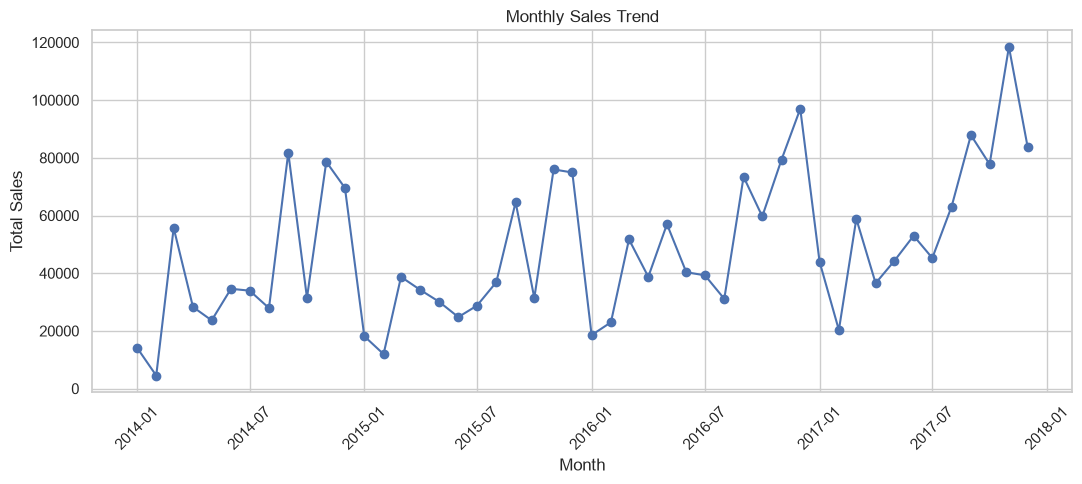

In [7]:
# Calculate monthly sales
monthly_sales = (
    df.set_index("Order Date")
      .resample("MS")["Sales"]
      .sum()
)

# Plot monthly sales trend
plt.figure(figsize=(11, 5))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Observation

Monthly sales fluctuate over time, with visible peaks and dips across different months. This indicates that sales are not completely consistent throughout the year.

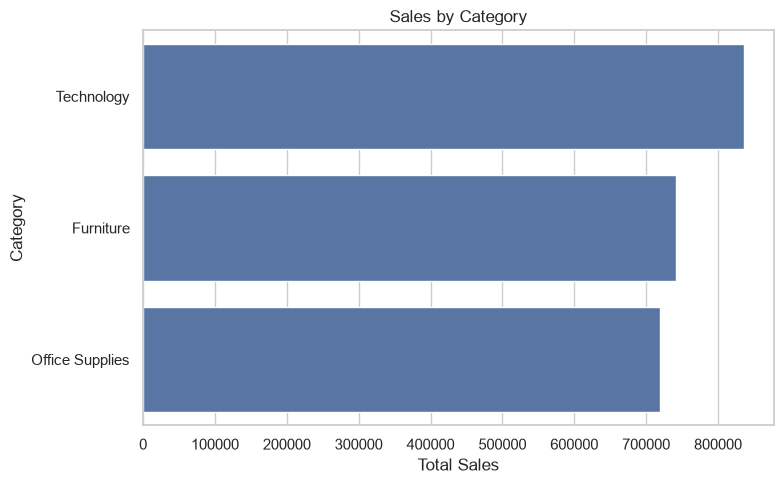

In [8]:
category_sales = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=category_sales.values,
    y=category_sales.index
)

plt.title("Sales by Category")
plt.xlabel("Total Sales")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

### Observation

Technology generates the highest total sales among the three product categories, followed by Furniture and Office Supplies.

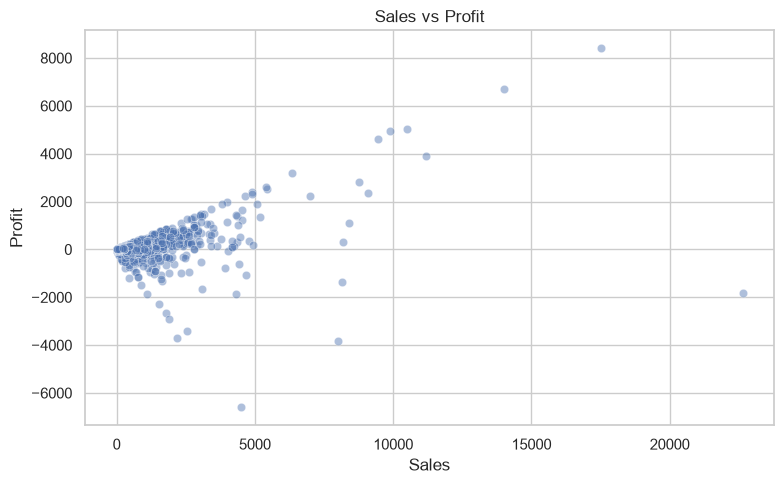

Sales-Profit Correlation: 0.4790643497377061


In [9]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Sales",
    y="Profit",
    alpha=0.45
)

plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")

plt.tight_layout()
plt.show()

correlation = df["Sales"].corr(df["Profit"])
print("Sales-Profit Correlation:", correlation)

### Observation

The scatter plot shows a generally positive relationship between Sales and Profit. However, some orders with high sales have relatively low or negative profit, showing that higher sales do not always guarantee higher profitability.

In [10]:
print("Top 3 Insights")

print("1. Technology has the highest total sales among the three product categories.")

print("2. Sales values are right-skewed, with most orders having lower sales and a smaller number of high-value orders.")

print("3. Sales and Profit show a generally positive relationship, but higher sales do not always result in higher profit.")

Top 3 Insights
1. Technology has the highest total sales among the three product categories.
2. Sales values are right-skewed, with most orders having lower sales and a smaller number of high-value orders.
3. Sales and Profit show a generally positive relationship, but higher sales do not always result in higher profit.


### Top 3 Insights

1. Technology has the highest total sales among the three product categories.
2. Sales values are right-skewed, with most orders having lower sales and a smaller number of high-value orders.
3. Sales and Profit show a generally positive relationship, but higher sales do not always result in higher profit.

## Day 2 – Exploratory Data Analysis (EDA)

### Objective

Performed Exploratory Data Analysis on the cleaned Sample Superstore dataset to identify patterns, trends, relationships, and key business insights.

### Tools Used

- Python
- Pandas
- Matplotlib
- Seaborn
- Jupyter Notebook

### Analysis Performed

- Dataset overview and summary statistics
- Sales distribution analysis
- Profit outlier analysis
- Monthly sales trend analysis
- Sales by category analysis
- Sales vs Profit relationship analysis

### Key Insights

1. Technology has the highest total sales among the three product categories.
2. Sales values are right-skewed, with most orders having lower sales and a smaller number of high-value orders.
3. Sales and Profit show a generally positive relationship, but higher sales do not always result in higher profit.

### Outcome

Completed Exploratory Data Analysis using the cleaned dataset and identified important sales and profitability patterns through statistical analysis and visualizations.

### Day 2 Notebook

[View EDA Notebook](./EDA_Day2.ipynb)